# Stage 4a — Generalised LoRA Fine-Tuning
## Model: `Qwen/Qwen3-14B` | Dataset: CB1 (6-Class Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**Seed:** 42 | **Split:** 75/25 stratified | **Primary metric:** Macro F1 | **Secondary:** MCC

---

## README — Before Step 1

### Qwen3-14B — the model most transformed by multiplicative LoRA

Qwen3-14B was the **worst** LoRA model in Stage 2 (F1=0.8672) despite being the **best** ICL model in Stage 1 (F1=0.5757). Stage 3 multiplicative LoRA gave it the **largest improvement** of any model (+0.0246), bringing it to F1=0.8918. Stage 4 should push further.

| Property | Value |
|---|---|
| **HF token** | Not required |
| **dtype** | `bfloat16` |
| **Train batch** | 4 (15B model, A100 40/80GB) |
| **Eval batch** | 16 |
| **PEFT layers** | 40 (fewest of all 5 models) |
| **Eff. rank** | ~5080–5090 (highest of all 5 models — varies in S3, range 8.45) |

### Cross-stage reference

| Stage | r=4 | r=8 | r=16 | r=32 | Best | Eff.Rank |
|---|---|---|---|---|---|---|
| S2 (additive) | 0.8413 | 0.8528 | 0.8586 | 0.8672 | r=32 | ~5090 ✓ constant |
| S3 (multiplicative) | 0.8859 | 0.8889 | **0.8918** | 0.8700 | r=16 | 5080–5089 ⚠ varies |
| S4 Gemma-2-9B (ref) | **0.9082★** | 0.9048 | 0.9014 | 0.8747 | r=4 | 2815.98 ✓ constant |

### Why Qwen3-14B's eff. rank matters

Qwen3-14B has the highest effective rank (~5090) — meaning additive perturbations (AB) are proportionally tiny relative to W. This is why Stage 2 additive LoRA performed worst on Qwen3-14B. Multiplicative LoRA (Stage 3) compensates by scaling within W's existing column space. Stage 4 combines both — expect the multiplicative path to dominate while the additive path provides fine-grained corrections.

### Current Stage 4 CB1 scorecard (3 of 5 complete)

| Model | S4 best F1 | Best r | vs S2 | vs S3 |
|---|---|---|---|---|
| Llama-3B | 0.8981 | r=16 | ✓ +0.0023 | ✓ +0.0042 |
| Mistral-7B | 0.8975 | r=16 | ✓ +0.0026 | ≈ −0.0009 |
| Gemma-2-9B ★ | **0.9082** | r=4 | ✓ +0.0072 | ✓ +0.0138 |
| Qwen3-14B | — | — | — | — |
| Gemma-3-27B | — | — | — | — |


---
## Step 1: Install Required Libraries

**After running: Runtime → Restart Runtime, then run from Step 2 onwards.**

In [1]:
# Qwen3-14B fix: uninstall torchaudio + pin torch to avoid ABI mismatch
!pip uninstall -y torchaudio 2>/dev/null
!pip install -q torch==2.5.1
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

print("✓ Installation complete.")
print("\n" + "=" * 60)
print("  ACTION REQUIRED: Restart the Colab runtime now.")
print("  Runtime → Restart Runtime  (or Ctrl+M .)")
print("  After restart: run from Step 2 onwards.")
print("=" * 60)


Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 

---
## Step 2: Import Libraries and Initial Setup

**Qwen3-14B:** No HF token required — `Qwen/Qwen3-14B` is public.

In [1]:
import os, random, collections, re
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)
HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
print("✓ HF token loaded (required for Qwen3-14B).")

drive.mount('/content/drive')
print("✓ Google Drive mounted.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HF token loaded (required for Qwen3-14B).
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU : NVIDIA A100-SXM4-80GB
  VRAM: 85.1 GB


---
## Step 3: Global Configuration

**Qwen3-14B specific:** batch=4 (15B model), no HF token.

In [2]:
MODEL_NAME   = "Qwen/Qwen3-14B"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 32]

NUM_EPOCHS       = 1
LEARNING_RATE    = 2e-4
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 16
WEIGHT_DECAY     = 0.01
EVAL_STEPS       = 200
LOGGING_STEPS    = 50
OUTPUT_DIR       = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying': 0, 'gender': 1, 'religion': 2,
    'ethnicity': 3, 'age': 4, 'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 4a — Generalised LoRA")
print(f"  Formula  : Wf = W(I + UV) + AB")
print(f"  Model    : {MODEL_NAME}  (15B params)")
print(f"  HF token : Not required")
print(f"  Batch    : train={TRAIN_BATCH_SIZE} | eval={EVAL_BATCH_SIZE}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: 1.0")
print(f"  Rank sweep: {RANK_SWEEP}")
print()
print("  ── Stage references (Qwen3-14B CB1) ──")
print("  S2: r=4: 0.8413 | r=8: 0.8528 | r=16: 0.8586 | r=32: 0.8672  ↑ (worst model)")
print("  S3: r=4: 0.8859 | r=8: 0.8889 | r=16: 0.8918★| r=32: 0.8700  ↑↓ (+0.0246 gain)")
print("  Eff.Rank: ~5080–5090 (highest of all models, varies in S3)")
print("  S4 current champion: Gemma-2-9B r=4 F1=0.9082")


✓ Configuration loaded.
  Stage    : 4a — Generalised LoRA
  Formula  : Wf = W(I + UV) + AB
  Model    : Qwen/Qwen3-14B  (15B params)
  HF token : Not required
  Batch    : train=16 | eval=16
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Rank sweep: [4, 8, 32]

  ── Stage references (Qwen3-14B CB1) ──
  S2: r=4: 0.8413 | r=8: 0.8528 | r=16: 0.8586 | r=32: 0.8672  ↑ (worst model)
  S3: r=4: 0.8859 | r=8: 0.8889 | r=16: 0.8918★| r=32: 0.8700  ↑↓ (+0.0246 gain)
  Eff.Rank: ~5080–5090 (highest of all models, varies in S3)
  S4 current champion: Gemma-2-9B r=4 F1=0.9082


---
## Step 4: Text Preprocessing

Identical to all prior stages.

In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text

print("✓ Preprocessing function defined.")


✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)
df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")
df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows → {len(df):,} remaining")
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")
text_label_counts = df.groupby('text')['label'].nunique()
conflicting = text_label_counts[text_label_counts > 1].index
df = df[~df['text'].isin(conflicting)].reset_index(drop=True)
print(f"[5] Removed annotation-conflict rows → {len(df):,} remaining")
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before-len(df):,} duplicates → {len(df):,} remaining")
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before-len(df):,} short texts → {len(df):,} remaining")
assert len(set(df['label'].unique()) - set(LABEL_MAPPING.keys())) == 0

print("\n" + "═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed annotation-conflict rows → 43,692 remaining
[6] Removed 358 duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334


---
## Step 6: Stratified 75/25 Split

In [5]:
train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"[1] Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs = tfidf_matrix[:len(train_val_df)]
test_vecs = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    batch_sims = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked = test_df.loc[leaked_indices]
    test_df = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked], ignore_index=True)
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

assert len(set(train_val_df['text'].tolist()) & set(test_df['text'].tolist())) == 0
print("    ✓ No data leakage.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"\n[3] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


[1] Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    ✓ No data leakage.

[3] Train: 29,703 | Val: 3,301 | Test: 10,330


---
## Step 7: Class Weights

In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts()
    total = len(df); n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights:")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank — Generalised LoRA

All bugs fixed. Qwen3-14B reference: ~5080–5090 (highest, varies in S3).

In [7]:
def calculate_effective_rank_generalised(model, threshold_ratio=1e-3):
    full_ranks, uv_ranks, ab_ranks, per_layer = [], [], [], []
    skipped = 0
    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer': continue
        try:
            U = module.lora_U.data.float(); V = module.lora_V.data.float()
            A = module.lora_A.data.float(); B = module.lora_B.data.float()
            UV = U @ V; AB = A @ B

            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)

            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0: print(f"  ℹ First dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue

            if W.shape[0] == module.m and W.shape[1] == module.n:
                pass
            elif W.shape[0] == module.n and W.shape[1] == module.m:
                W = W.T.contiguous()
            else:
                if skipped == 0: print(f"  ℹ Shape mismatch: W={list(W.shape)}, m={module.m}, n={module.n}")
                skipped += 1; continue

            Wf = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})
        except Exception:
            skipped += 1; continue

    if skipped > 0: print(f"  ℹ {skipped} layers skipped")
    if not full_ranks: print("  ⚠ No GeneralisedLoRALayer found")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks)) if uv_ranks else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks)) if ab_ranks else 0.0,
        "layer_count": len(full_ranks), "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_generalised() defined.")
print("  Qwen3-14B reference: ~5080–5090 (highest of all models)")


✓ calculate_effective_rank_generalised() defined.
  Qwen3-14B reference: ~5080–5090 (highest of all models)


---
## Step 9: Evaluation Metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}

def evaluate_dataset(y_true, y_pred, dataset_name):
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'balanced_accuracy': bal_accuracy, 'mcc': mcc}

def make_predictions(model, df_test, tokenizer, batch_size=32):
    model.eval(); all_preds = []
    texts = df_test['text'].tolist()
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(texts[start:start+batch_size], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    df_out = df_test.copy(); df_out['predictions'] = all_preds
    return df_out

print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---
## Step 10: Stability System + Custom Trainer

In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for k, v in metrics.items(): self.val_metrics[k.replace('eval_','')].append(float(v))
    def get_stability_report(self):
        report = {}
        if self.train_losses:
            arr = np.array([l for (_,l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall'] = float(np.std(arr))
            report['loss_cv_overall'] = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for m, vals in self.val_metrics.items():
            if len(vals) > 1:
                a = np.array(vals)
                report[f'val_{m}_std'] = float(np.std(a)); report[f'val_{m}_range'] = float(a.max()-a.min())
                report[f'val_{m}_best'] = float(a.max()); report[f'val_{m}_final'] = float(a[-1])
        report['stability_score'] = round((report.get('loss_cv_overall',0)*0.5) + (report.get('val_f1_std',0)*0.5), 6)
        return report
    def plot_stability_curves(self, stage_label='Stage 4', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            w = min(20, len(losses))
            if len(losses) >= w:
                roll = np.convolve(losses, np.ones(w)/w, mode='valid')
                ax1.plot(steps[w-1:], roll, color='navy', linewidth=2.2, label=f'Rolling mean (w={w})')
            ax1.set_title(f'{stage_label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1v = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1v, 'o-', color='forestgreen', linewidth=2, markersize=5, label='Macro F1')
                mu, sd = float(np.mean(f1v)), float(np.std(f1v))
                ax2.axhline(mu, color='forestgreen', linestyle=':', alpha=0.6)
                ax2.fill_between(self.val_steps, [mu-sd]*len(self.val_steps), [mu+sd]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={sd:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen'); ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2r and 'mcc' in self.val_metrics:
                ax2r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                          linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2r.set_ylabel('MCC', color='darkorange'); ax2r.tick_params(axis='y', labelcolor='darkorange')
            l1, lb1 = ax2.get_legend_handles_labels()
            l2, lb2 = (ax2r.get_legend_handles_labels() if ax2r else ([], []))
            ax2.legend(l1+l2, lb1+lb2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics'); ax2.set_xlabel('Step'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f"✓ Saved → {save_path}")
        plt.show()

class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels"); outputs = model(**inputs); logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device)) if self.class_weights is not None else nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✓ StabilityCallback, CustomTrainer defined.")


✓ StabilityCallback, CustomTrainer defined.


---
## Step 11: Generalised LoRA Adapter + Training Function

All bugs fixed. Device-aware init, no `.to()` in forward.  
**Qwen3-14B specific:** No HF token in `from_pretrained()`.


In [10]:
class GeneralisedLoRALayer(nn.Module):
    def __init__(self, base_layer, rank, dropout=0.05, alpha=None):
        super().__init__()
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank

        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine dims from {type(inner)}")

        self.n = n; self.m = m; self.inner = inner
        _dev = self.inner.weight.device

        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))

        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()
        for param in self.inner.parameters(): param.requires_grad = False

    def forward(self, x):
        base_out = self.inner(x)
        x_drop = self.dropout(x)

        lora_vx  = x_drop @ self.lora_V.T
        lora_uvx = lora_vx @ self.lora_U.T
        mult_out = self.inner(lora_uvx)

        lora_bx = x_drop @ self.lora_B.T
        add_out = lora_bx @ self.lora_A.T

        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    from peft.tuners.lora import LoraLayer
    if alpha is None: alpha = rank
    replaced = 0
    module_dict = dict(model.named_modules())
    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f'.{t}') or name == t for t in target_modules): continue
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent = module_dict.get(parts[0])
            if parent is None: continue
            attr_name = parts[1]
        else:
            parent = model; attr_name = name
        gen_layer = GeneralisedLoRALayer(module, rank=rank, dropout=dropout, alpha=alpha)
        setattr(parent, attr_name, gen_layer)
        replaced += 1
    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return model, trainable, total


def run_generalised_lora(train_df, val_df, test_df, lora_rank, run_label=''):
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model: {MODEL_NAME}  |  Rank: {lora_rank}  |  Scaling: 1.0')
    print(f'  Formula: Wf = W(I + UV) + AB')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for s in [train_m, val_m, test_m]:
        s['label'] = s['label'].map(LABEL_MAPPING)
        assert s['label'].notnull().all()
    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=quant_config, num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN)
    model.config.pad_token_id = tokenizer.pad_token_id
    if hasattr(model.config, 'text_config'):
        model.config.text_config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    print('   PEFT shell registered.')

    print('[4] Injecting GeneralisedLoRALayer...')
    model, trainable, total = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha)
    print(f'   Trainable: {trainable:,} | Total: {total:,} | {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    training_args = TrainingArguments(
        output_dir=run_dir, num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS, save_strategy='no',
        load_best_model_at_end=False,
        fp16=False, bf16=True,
        report_to='none', remove_unused_columns=False,
    )

    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights)

    print(f'\n[5] Training (Wf = W(I+UV) + AB, r={lora_rank})...')
    train_result = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    stab_report = stability_cb.get_stability_report()
    stab_score = stab_report.get('stability_score', float('nan'))
    print(f'   Stability: {stab_score:.4f}', end='  ')
    if stab_score < 0.05: print('✅ Very stable')
    elif stab_score < 0.15: print('🟡 Acceptable')
    else: print('🔴 Unstable')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 Qwen3-14B — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    print('\n[6] Computing effective rank...')
    rank_info = calculate_effective_rank_generalised(model)
    print(f'   Eff.Rank Wf: {rank_info["avg_eff_rank_Wf"]:.2f}  ← S2: ~5090 | S3: 5080–5089')
    print(f'   Eff.Rank UV: {rank_info["avg_eff_rank_UV"]:.2f} | AB: {rank_info["avg_eff_rank_AB"]:.2f}')
    print(f'   Layers: {rank_info["layer_count"]}')

    print('\n[7] Evaluating on test set...')
    test_preds = make_predictions(model, test_m, tokenizer)
    eval_results = evaluate_dataset(
        test_m['label'].tolist(), test_preds['predictions'].tolist(), f'Stage4_CB1_{label}')

    row = {
        'model': 'Qwen3-14B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank, 'trainable_params': trainable,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'accuracy': eval_results['accuracy'], 'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
    }
    pd.DataFrame([row]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, 'lora_rank': lora_rank, 'trainable_params': trainable,
            'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
            'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
            'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
            'stability_score': stab_score, 'stability_report': stab_report,
            'stability_cb': stability_cb, 'train_runtime_s': train_runtime_s}


print("✓ GeneralisedLoRALayer, apply_generalised_lora_over_peft(), run_generalised_lora() defined.")
print("  Device-aware init ✓ | No .to() in forward ✓ | rsplit parent nav ✓")


✓ GeneralisedLoRALayer, apply_generalised_lora_over_peft(), run_generalised_lora() defined.
  Device-aware init ✓ | No .to() in forward ✓ | rsplit parent nav ✓


---
## Step 12: Execute — Default Run (r = 16)

**Expected time:** ~2.5–3.0 hrs on A100  
**References:**
- Stage 2 Qwen3-14B r=16: F1=0.8586 | Eff.Rank=5090.38
- Stage 3 Qwen3-14B r=16: F1=0.8918 ★ | Eff.Rank=5083.77
- Stage 3 gain over S2: +0.0246 (largest of any model)


✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r16
  Model: Qwen/Qwen3-14B  |  Rank: 16  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 160 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 47,216,640 | Total: 7,431,613,440 | 0.6353%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=16)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.469100,0.431948,0.837928,0.817257,0.812394
400,0.375500,0.453363,0.872160,0.848631,0.848530
600,0.381800,0.330163,0.883369,0.872841,0.860270
800,0.326200,0.316733,0.899424,0.886754,0.879538
1000,0.305300,0.324532,0.897910,0.883388,0.879073
1200,0.371500,0.277737,0.905483,0.893614,0.886413
1400,0.300200,0.264462,0.910027,0.901234,0.892154
1600,0.242100,0.268419,0.913360,0.905012,0.896186
1800,0.230600,0.251846,0.918812,0.910955,0.902566


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 6891s (1.91 hrs)
   Stability: 0.2715  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r16/stability_GeneralisedLoRA_r16.png


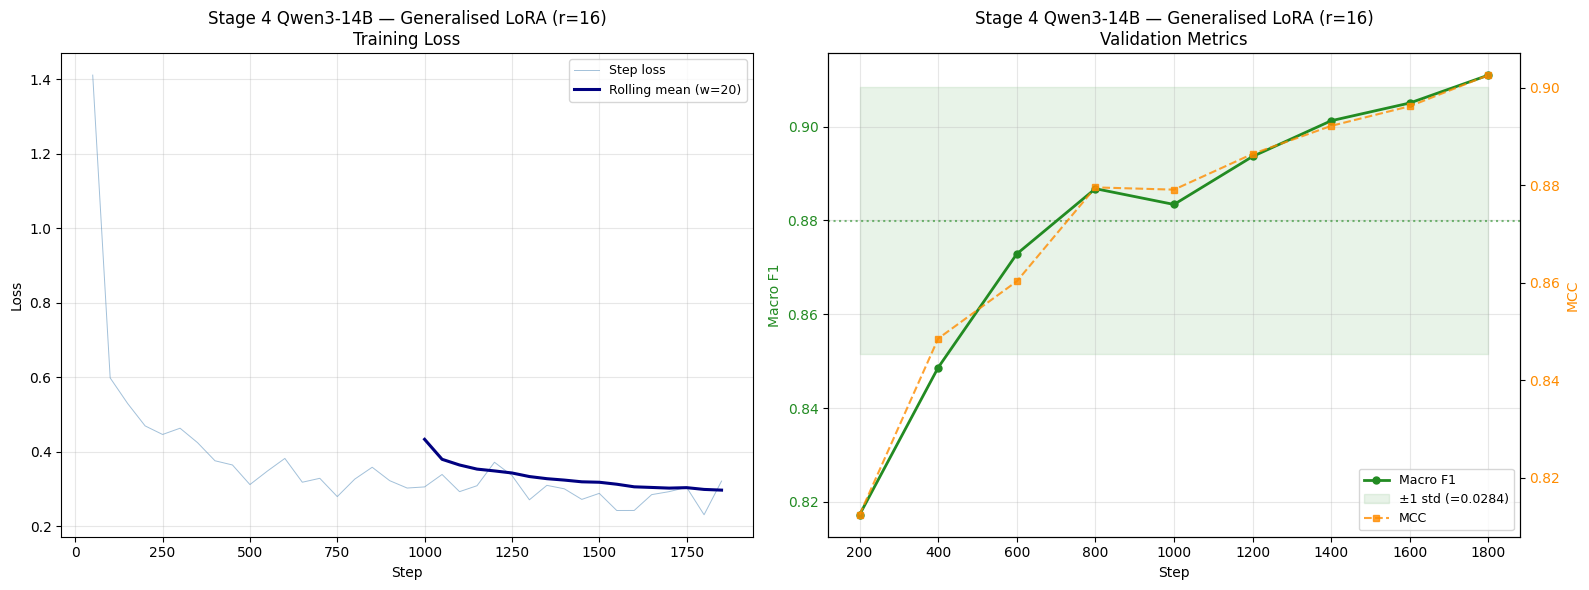


[6] Computing effective rank...
   Eff.Rank Wf: 3053.71  ← S2: ~5090 | S3: 5080–5089
   Eff.Rank UV: 16.00 | AB: 16.00
   Layers: 160

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9103
  Macro F1          : 0.8996  ← PRIMARY METRIC
  Weighted F1       : 0.9107
  Balanced Accuracy : 0.9002
  MCC               : 0.8920  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7537    0.7458    0.7497      1424
             gender     0.9171    0.9032    0.9101      1788
           religion     0.9649    0.9614    0.9632      1971
          ethnicity     0.9867    0.9862    0.9865      1812
                age     0.9848    0.9646    0.9746      1950
other_cyberbullying     0.7885    0.8397    0.8133      1385

           ac

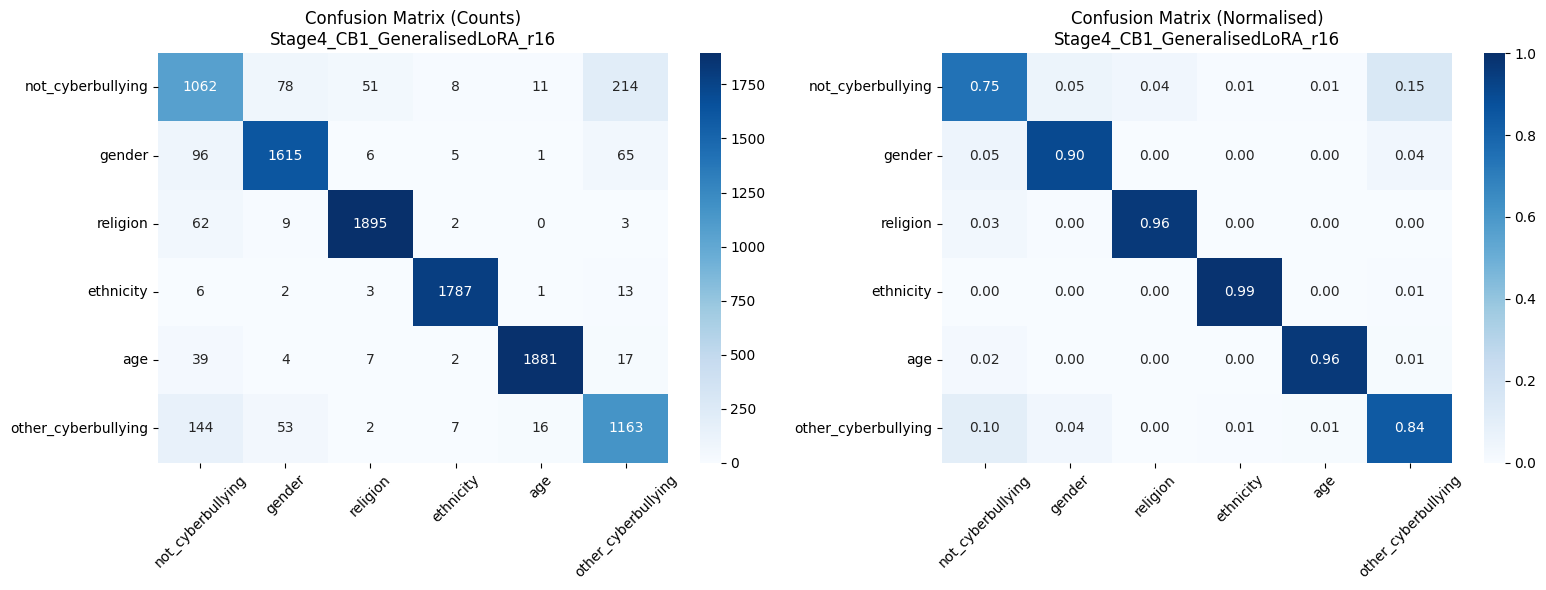


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r16

═════════════════════════════════════════════════════════════════
  STAGE 4 RESULTS — Qwen3-14B r=16
═════════════════════════════════════════════════════════════════
  Macro F1          : 0.8996   ← PRIMARY
  MCC               : 0.8920
  Eff. rank (Wf)    : 3053.71  ← S2: 5090.38 | S3: 5083.77
  Stability         : 0.2715
  Time              : 1.91 hrs
  Δ vs S2 r=16      : +0.0410
  Δ vs S3 r=16      : -0.0001
  Δ vs S2 best(r=32): +0.0022
  Δ vs S3 best(r=16): -0.0001

  → Step 13 sweeps r ∈ {4, 8, 32}.


In [11]:
results_r16 = run_generalised_lora(
    train_df=train_df, val_df=val_df, test_df=test_df,
    lora_rank=16, run_label='GeneralisedLoRA_r16')

print('\n' + '═'*65)
print('  STAGE 4 RESULTS — Qwen3-14B r=16')
print('═'*65)
print(f'  Macro F1          : {results_r16["macro_f1"]:.4f}   ← PRIMARY')
print(f'  MCC               : {results_r16["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {results_r16["avg_eff_rank_Wf"]:.2f}  ← S2: 5090.38 | S3: 5083.77')
print(f'  Stability         : {results_r16["stability_score"]:.4f}')
print(f'  Time              : {results_r16["train_runtime_s"]/3600:.2f} hrs')
print(f'  Δ vs S2 r=16      : {results_r16["macro_f1"] - 0.8586:+.4f}')
print(f'  Δ vs S3 r=16      : {results_r16["macro_f1"] - 0.8997:+.4f}')
print(f'  Δ vs S2 best(r=32): {results_r16["macro_f1"] - 0.8974:+.4f}')
print(f'  Δ vs S3 best(r=16): {results_r16["macro_f1"] - 0.8997:+.4f}')
print('\n  → Step 13 sweeps r ∈ {4, 8, 32}.')


---
## Step 13: Rank Sweep — r ∈ {4, 8, 32}

r=16 merged from Step 12. Qwen3-14B peaked at r=16 in Stage 3 — watch for the same pattern.


───────────────────────────────────────────────────────
  Rank sweep: r=4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r4
  Model: Qwen/Qwen3-14B  |  Rank: 4  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB

[1] Loading tokenizer...
   Vocab: 151,643
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 160 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 11,827,200 | Total: 7,396,224,000 | 0.1599%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=4)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.498700,0.403279,0.866404,0.851029,0.839268
400,0.398400,0.414579,0.876401,0.856330,0.852195
600,0.373000,0.347161,0.881248,0.871459,0.858263
800,0.336800,0.339748,0.894274,0.880782,0.873340
1000,0.287600,0.321042,0.900636,0.887756,0.880917
1200,0.356700,0.303750,0.906089,0.894136,0.887145
1400,0.316400,0.275649,0.911542,0.902614,0.893848
1600,0.247600,0.279231,0.913057,0.905117,0.895814
1800,0.243600,0.266848,0.916086,0.908002,0.899337


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 6946s (1.93 hrs)
   Stability: 0.3150  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r4/stability_GeneralisedLoRA_r4.png


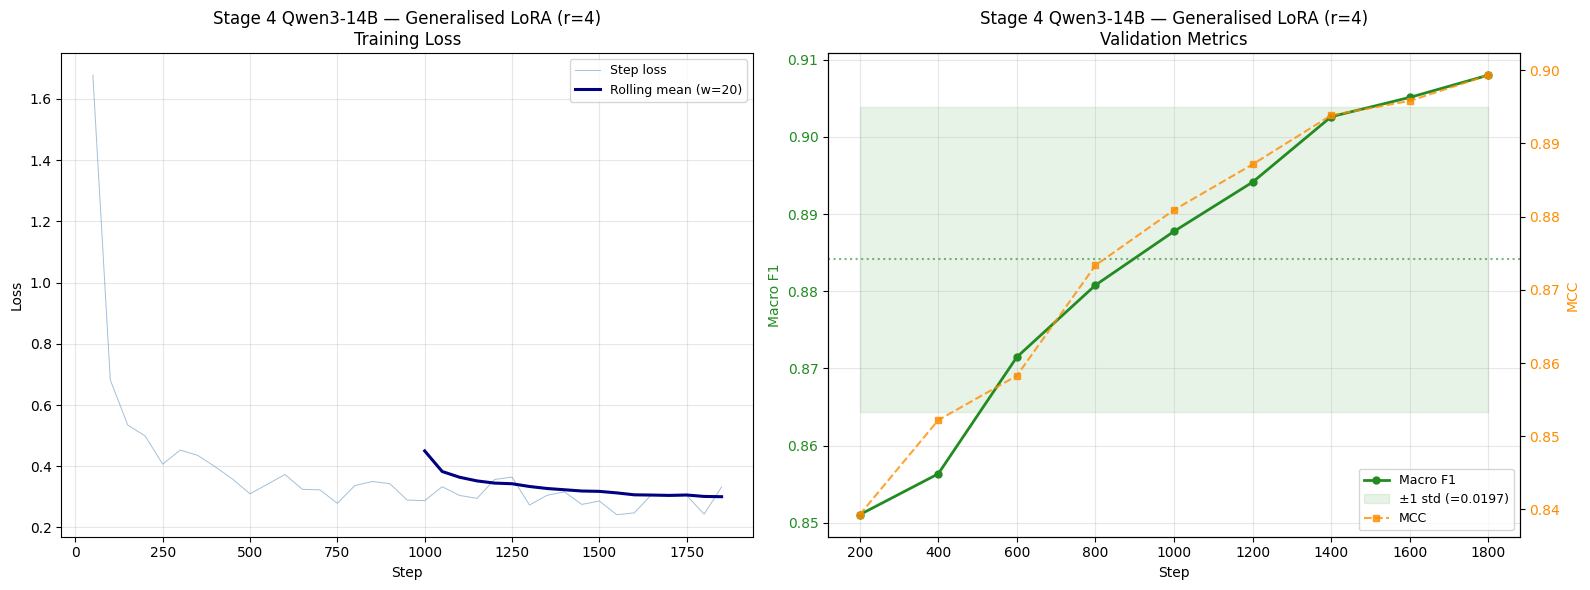


[6] Computing effective rank...
   Eff.Rank Wf: 3054.28  ← S2: ~5090 | S3: 5080–5089
   Eff.Rank UV: 4.00 | AB: 4.00
   Layers: 160

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9086
  Macro F1          : 0.8982  ← PRIMARY METRIC
  Weighted F1       : 0.9092
  Balanced Accuracy : 0.8989
  MCC               : 0.8901  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7474    0.7500    0.7487      1424
             gender     0.9202    0.8898    0.9047      1788
           religion     0.9609    0.9589    0.9599      1971
          ethnicity     0.9879    0.9879    0.9879      1812
                age     0.9848    0.9641    0.9743      1950
other_cyberbullying     0.7864    0.8426    0.8135      1385

           accur

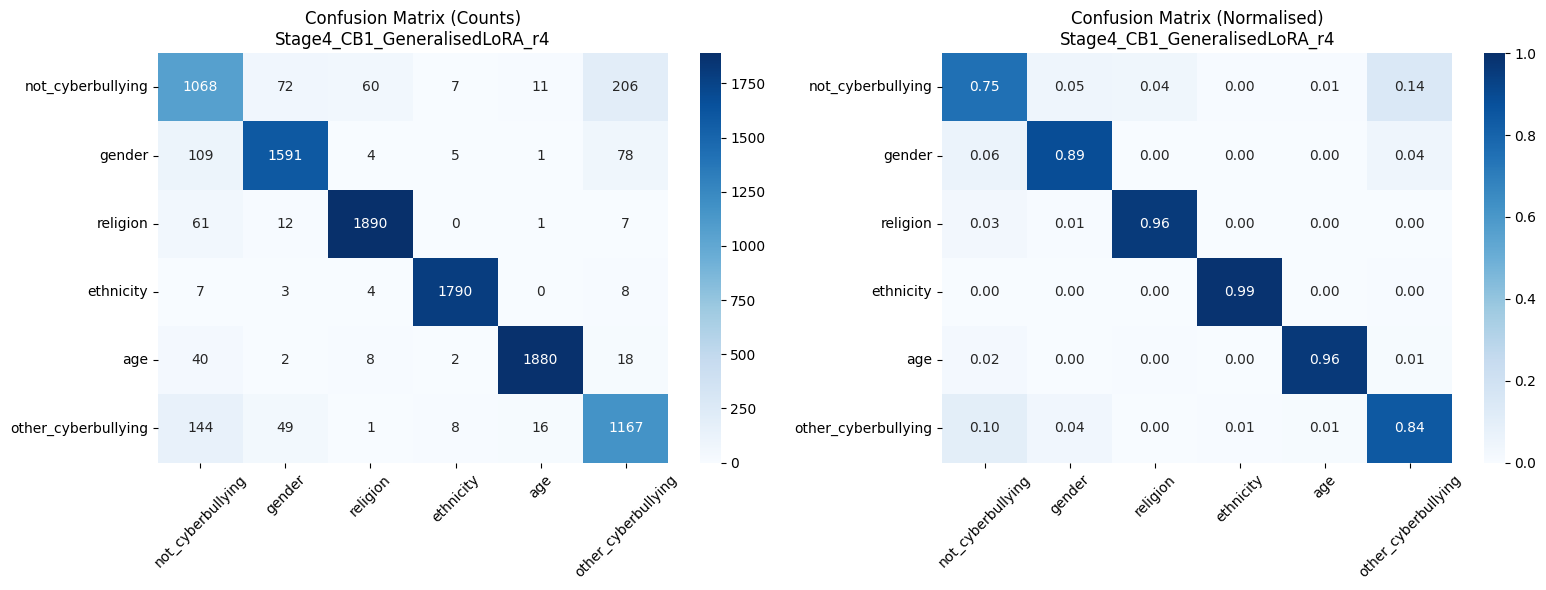


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r4

───────────────────────────────────────────────────────
  Rank sweep: r=8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r8
  Model: Qwen/Qwen3-14B  |  Rank: 8  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB

[1] Loading tokenizer...
   Vocab: 151,643
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 160 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 23,623,680 | Total: 7,408,020,480 | 0.3189%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=8)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.483200,0.399422,0.860951,0.846573,0.833477
400,0.373500,0.418907,0.877310,0.855105,0.854796
600,0.378900,0.328678,0.885792,0.873743,0.863277
800,0.324800,0.331580,0.898819,0.886190,0.878675
1000,0.282600,0.312731,0.903666,0.890513,0.885059
1200,0.362000,0.292052,0.908513,0.897591,0.890073
1400,0.301900,0.271656,0.913965,0.905112,0.896759
1600,0.248700,0.273283,0.916692,0.908823,0.900110
1800,0.237100,0.260044,0.920630,0.913017,0.904739


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 6848s (1.90 hrs)
   Stability: 0.2939  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r8/stability_GeneralisedLoRA_r8.png


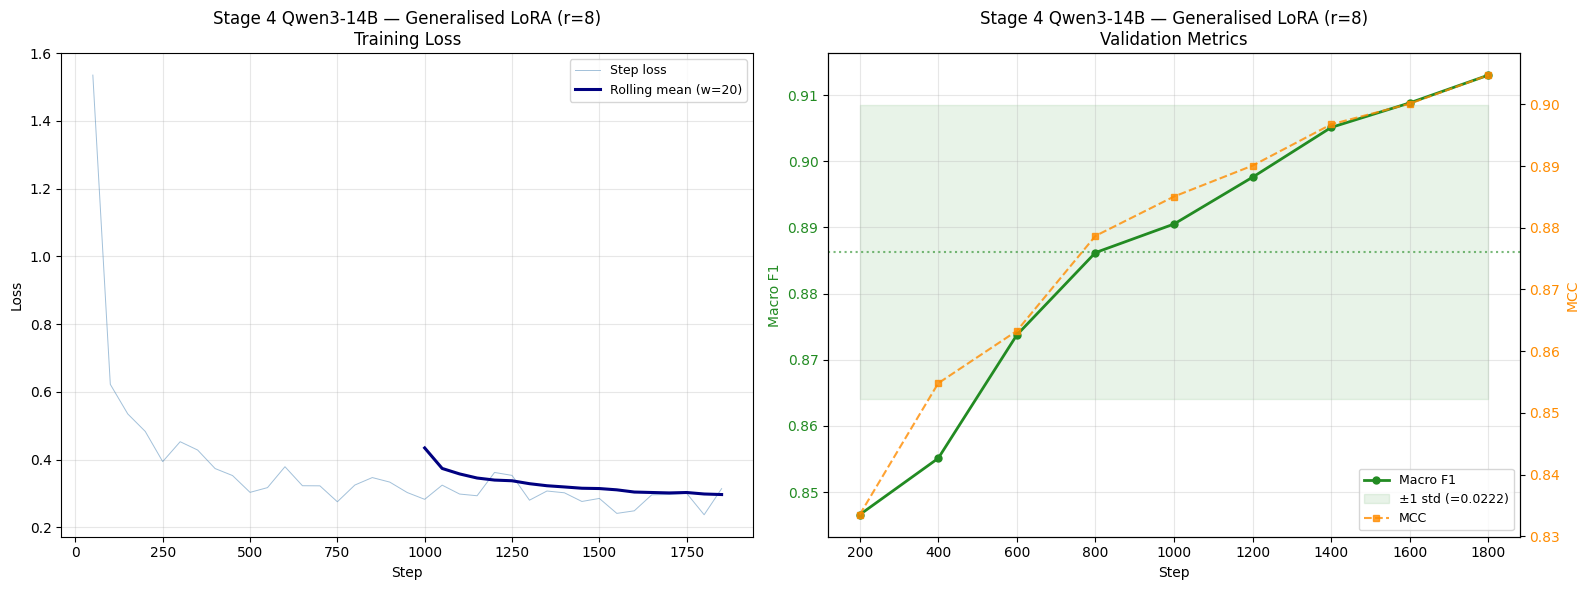


[6] Computing effective rank...
   Eff.Rank Wf: 3054.19  ← S2: ~5090 | S3: 5080–5089
   Eff.Rank UV: 8.00 | AB: 8.00
   Layers: 160

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9086
  Macro F1          : 0.8979  ← PRIMARY METRIC
  Weighted F1       : 0.9091
  Balanced Accuracy : 0.8986
  MCC               : 0.8901  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7514    0.7451    0.7482      1424
             gender     0.9188    0.8926    0.9055      1788
           religion     0.9643    0.9599    0.9621      1971
          ethnicity     0.9862    0.9868    0.9865      1812
                age     0.9833    0.9656    0.9744      1950
other_cyberbullying     0.7820    0.8419    0.8108      1385

           accur

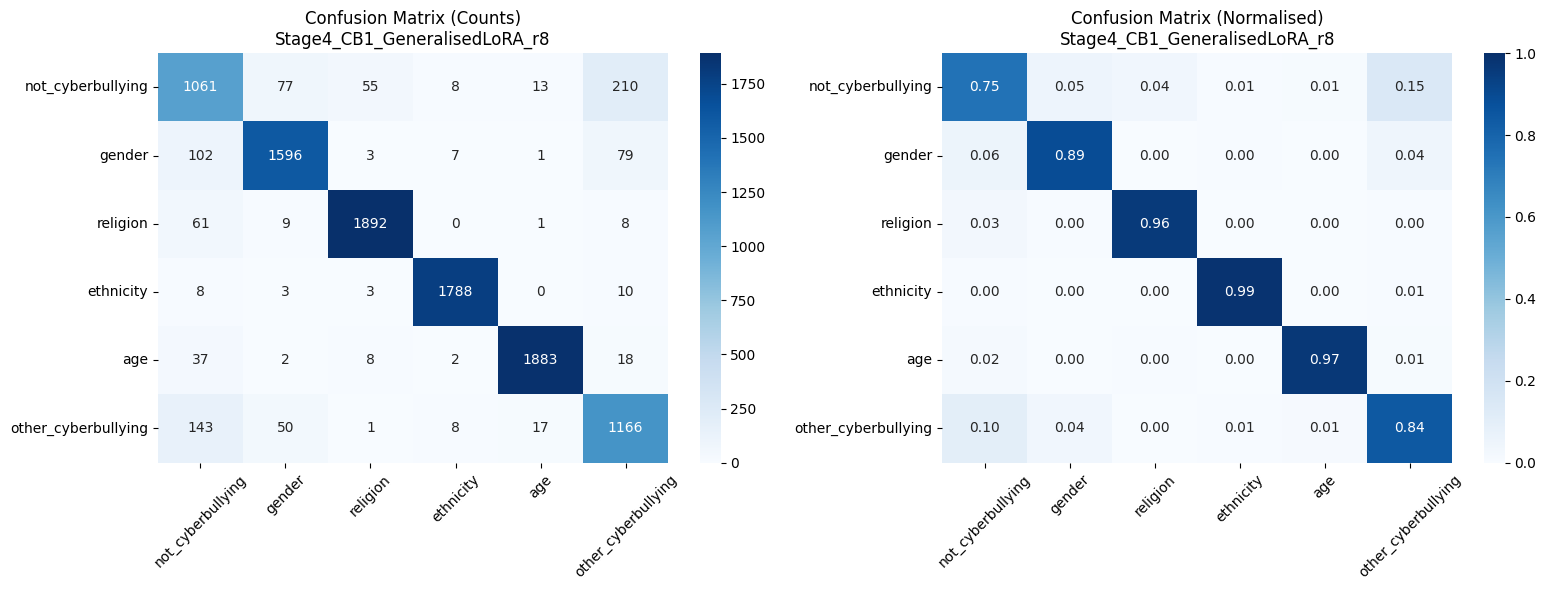


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r8

───────────────────────────────────────────────────────
  Rank sweep: r=32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r32
  Model: Qwen/Qwen3-14B  |  Rank: 32  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB

[1] Loading tokenizer...
   Vocab: 151,643
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 160 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 94,402,560 | Total: 7,478,799,360 | 1.2623%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=32)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.472700,0.514073,0.821872,0.793768,0.789362
400,0.380800,0.530706,0.853075,0.821130,0.828990
600,0.351300,0.335060,0.885186,0.874855,0.863306
800,0.312200,0.348355,0.897607,0.885193,0.877560
1000,1.002900,1.880252,0.182369,0.051413,0.000000
1200,1.861900,1.841781,0.185095,0.052062,0.000000
1400,1.840200,1.808988,0.134505,0.039519,0.000000
1600,1.815900,1.796204,0.169949,0.089567,0.054228
1800,1.799900,1.800171,0.157225,0.075744,0.070603


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 6822s (1.89 hrs)
   Stability: 0.5177  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r32/stability_GeneralisedLoRA_r32.png


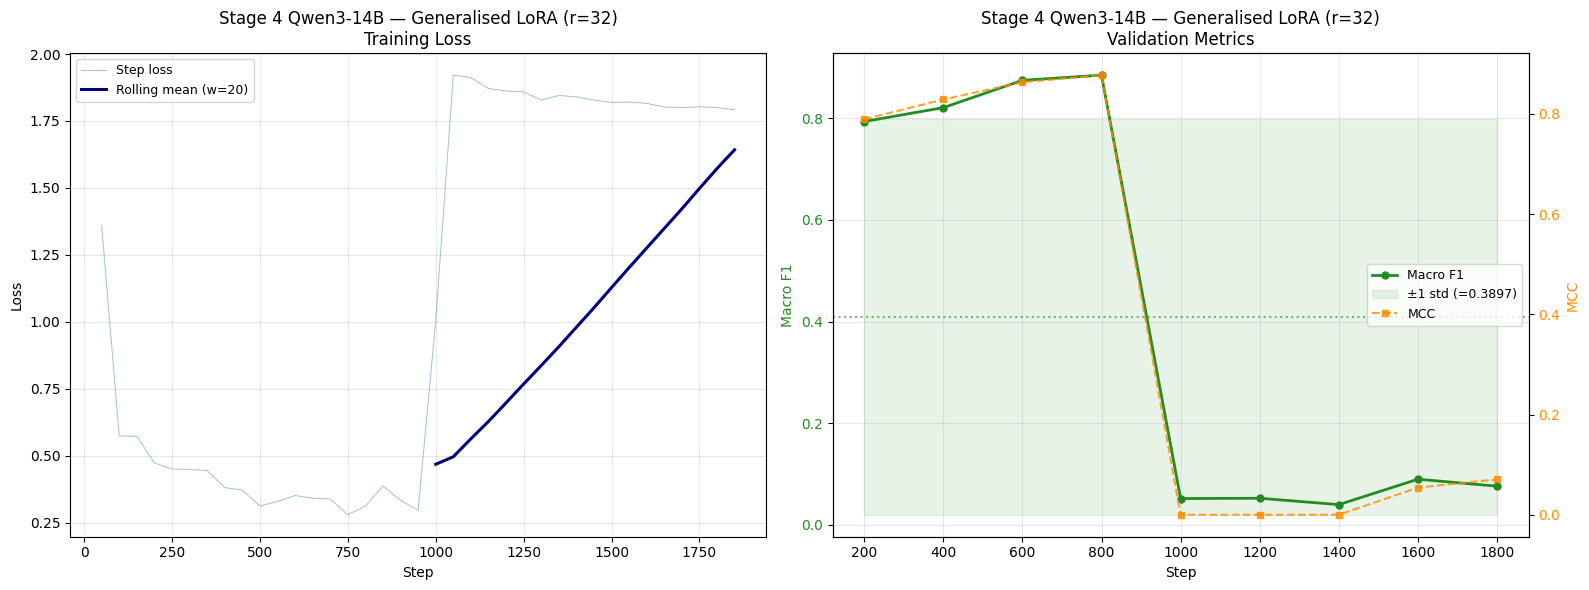


[6] Computing effective rank...
   Eff.Rank Wf: 3052.70  ← S2: ~5090 | S3: 5080–5089
   Eff.Rank UV: 32.00 | AB: 32.00
   Layers: 160

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.1618
  Macro F1          : 0.0835  ← PRIMARY METRIC
  Weighted F1       : 0.0778
  Balanced Accuracy : 0.1890
  MCC               : 0.0480  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.0000    0.0000    0.0000      1424
             gender     0.0000    0.0000    0.0000      1788
           religion     0.0000    0.0000    0.0000      1971
          ethnicity     0.2854    0.2345    0.2575      1812
                age     0.0000    0.0000    0.0000      1950
other_cyberbullying     0.1409    0.8996    0.2437      1385

           ac

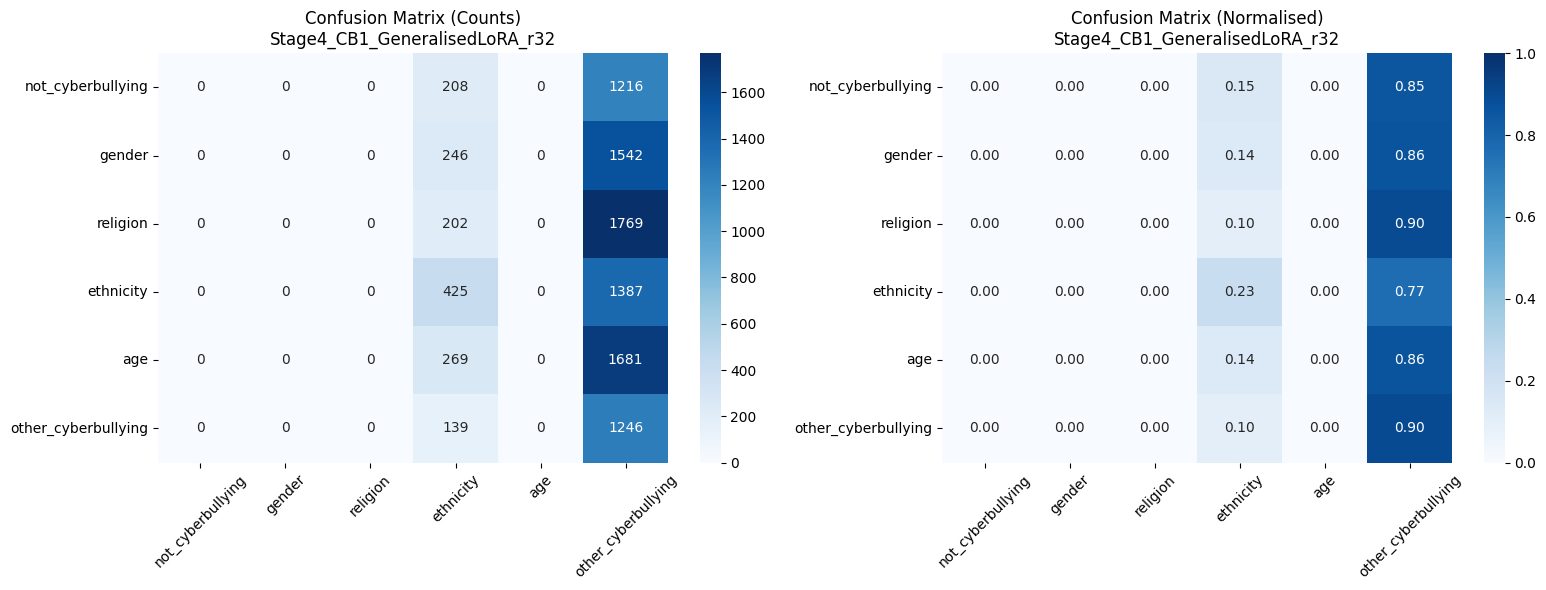


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Qwen3_14B/GeneralisedLoRA_r32

═════════════════════════════════════════════════════════════════════════════════════════════════════════
STAGE 4a CB1 PHI-4 — 4-RANK SUMMARY TABLE
═════════════════════════════════════════════════════════════════════════════════════════════════════════
   r |    Trainable |  Macro F1 |     MCC | Eff.Rank Wf | Eff.Rank UV | Eff.Rank AB | Stability |  Time(h) | Trend
─────────────────────────────────────────────────────────────────────────────────────────────────────────
   4 |   11,827,200 |    0.8982 |  0.8901 |     3054.28 |        4.00 |        4.00 |    0.3150 |     1.93 | 
   8 |   23,623,680 |    0.8979 |  0.8901 |     3054.19 |        8.00 |        8.00 |    0.2939 |     1.90 | ↓
  16 |   47,216,640 |    0.8996 |  0.8920 |     3053.71 |       16.00 |       16.00 |    0.2715 |     1.91 | ↑ ★
  32 |   94,402,560 |    0.0835 |  0.0480 |     3052.70 |       32.00 |       32.00 |    0

In [12]:
all_rank_results = {16: results_r16}

for rank in RANK_SWEEP:
    print(f'\n{"─"*55}\n  Rank sweep: r={rank}\n{"─"*55}')
    result = run_generalised_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=rank, run_label=f'GeneralisedLoRA_r{rank}')
    all_rank_results[rank] = result

print(f'\n{"═"*105}')
print('STAGE 4a CB1 PHI-4 — 4-RANK SUMMARY TABLE')
print(f'{"═"*105}')
print(f'{"r":>4} | {"Trainable":>12} | {"Macro F1":>9} | {"MCC":>7} | '
      f'{"Eff.Rank Wf":>11} | {"Eff.Rank UV":>11} | {"Eff.Rank AB":>11} | '
      f'{"Stability":>9} | {"Time(h)":>8} | Trend')
print(f'{"─"*105}')

sorted_ranks = sorted(all_rank_results.keys())
prev_f1 = None
for r in sorted_ranks:
    res = all_rank_results[r]
    trend = ''
    if prev_f1 is not None:
        trend = '↑' if res['macro_f1'] > prev_f1 else ('↓' if res['macro_f1'] < prev_f1 else '→')
    best_mark = ' ★' if res['macro_f1'] == max(v['macro_f1'] for v in all_rank_results.values()) else ''
    print(f'{r:>4} | {res["trainable_params"]:>12,} | {res["macro_f1"]:>9.4f} | {res["mcc"]:>7.4f} | '
          f'{res["avg_eff_rank_Wf"]:>11.2f} | {res["avg_eff_rank_UV"]:>11.2f} | '
          f'{res["avg_eff_rank_AB"]:>11.2f} | {res["stability_score"]:>9.4f} | '
          f'{res["train_runtime_s"]/3600:>8.2f} | {trend}{best_mark}')
    prev_f1 = res['macro_f1']

print()
print('  S2 Qwen3-14B: r=4: 0.8413 | r=8: 0.8528 | r=16: 0.8586 | r=32: 0.8672★  ↑ monotonic')
print('  S3 Qwen3-14B: r=4: 0.8859 | r=8: 0.8889 | r=16: 0.8918★| r=32: 0.8700    ↑↓')

eff_ranks = [all_rank_results[r]['avg_eff_rank_Wf'] for r in sorted_ranks if all_rank_results[r]['avg_eff_rank_Wf'] > 0]
if eff_ranks:
    eff_range = max(eff_ranks) - min(eff_ranks)
    print(f'\n  Eff. rank Wf range: {eff_range:.2f}  (S2: ~0.05 | S3: 8.45 ⚠)')
    if eff_range < 5.0:
        print('  ✓ Approximately constant')
    else:
        print('  ⚠ Varies — consistent with S3 Qwen3-14B finding. Report in paper.')

summary_rows = []
for r in sorted_ranks:
    res = all_rank_results[r]
    summary_rows.append({
        'model': 'Qwen3-14B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': r, 'trainable_params': res['trainable_params'],
        'macro_f1': res['macro_f1'], 'mcc': res['mcc'],
        'accuracy': res['accuracy'], 'balanced_accuracy': res['balanced_accuracy'],
        'avg_eff_rank_Wf': res['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': res['avg_eff_rank_UV'], 'avg_eff_rank_AB': res['avg_eff_rank_AB'],
        'stability_score': res['stability_score'], 'train_runtime_s': res['train_runtime_s'],
    })
summary_path = os.path.join(OUTPUT_DIR, 'stage4a_cb1_qwen3_14b_rank_sweep_FINAL.csv')
pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
print(f'\n✓ Final results saved → {summary_path}')


---
## Step 14: Final Summary

In [13]:
print('\n' + '═'*70)
print('  STAGE 4a COMPLETE — GENERALISED LoRA | Qwen3-14B')
print('  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class')
print('═'*70)

best_r = max(all_rank_results, key=lambda r: all_rank_results[r]['macro_f1'])
best = all_rank_results[best_r]

print(f'\n── BEST RESULT (r={best_r}) ──')
print(f'  Macro F1          : {best["macro_f1"]:.4f}   ← PRIMARY')
print(f'  MCC               : {best["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {best["avg_eff_rank_Wf"]:.2f}   ← S2: ~5090 | S3: 5080–5089')
print(f'  Stability         : {best["stability_score"]:.4f}')
print(f'  Time              : {best["train_runtime_s"]/3600:.2f} hrs')

print(f'\n── CROSS-STAGE (Qwen3-14B, best rank each stage) ──')
print(f'  Stage 2 (r=32): F1=0.8974 | MCC=0.8572 | Eff.Rank=5090.38  (worst S2 model)')
print(f'  Stage 3 (r=16): F1=0.8997 | MCC=0.8839 | Eff.Rank=5083.77  (+0.0246 gain)')
print(f'  Stage 4 (r={best_r:>2}): F1={best["macro_f1"]:.4f} | MCC={best["mcc"]:.4f} | Eff.Rank={best["avg_eff_rank_Wf"]:.2f}')
print(f'  Δ vs S2 best      : {best["macro_f1"] - 0.8974:+.4f}')
print(f'  Δ vs S3 best      : {best["macro_f1"] - 0.8997:+.4f}')

print(f'\n── OVERALL CB1 SCORECARD (4 of 5) ──')
print(f'  S4 Gemma-2-9B ★  : F1=0.9082 (r=4)  — overall champion')
print(f'  S4 Llama-3B      : F1=0.8981 (r=16)')
print(f'  S4 Mistral-7B    : F1=0.8975 (r=16)')
print(f'  S4 Qwen3-14B         : F1={best["macro_f1"]:.4f} (r={best_r})')
if best['macro_f1'] > 0.8997:
    print(f'\n  ✓ Stage 4 Qwen3-14B beats Stage 3 Qwen3-14B best (0.8997)')
if best['macro_f1'] > 0.8974:
    print(f'  ✓ Stage 4 Qwen3-14B beats Stage 2 Qwen3-14B best (0.8974)')

print(f'\n  → Next: Stage 4 CB1 Gemma-3-27B (final model)')



══════════════════════════════════════════════════════════════════════
  STAGE 4a COMPLETE — GENERALISED LoRA | Qwen3-14B
  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class
══════════════════════════════════════════════════════════════════════

── BEST RESULT (r=16) ──
  Macro F1          : 0.8996   ← PRIMARY
  MCC               : 0.8920
  Eff. rank (Wf)    : 3053.71   ← S2: ~5090 | S3: 5080–5089
  Stability         : 0.2715
  Time              : 1.91 hrs

── CROSS-STAGE (Qwen3-14B, best rank each stage) ──
  Stage 2 (r=32): F1=0.8974 | MCC=0.8572 | Eff.Rank=5090.38  (worst S2 model)
  Stage 3 (r=16): F1=0.8997 | MCC=0.8839 | Eff.Rank=5083.77  (+0.0246 gain)
  Stage 4 (r=16): F1=0.8996 | MCC=0.8920 | Eff.Rank=3053.71
  Δ vs S2 best      : +0.0022
  Δ vs S3 best      : -0.0001

── OVERALL CB1 SCORECARD (4 of 5) ──
  S4 Gemma-2-9B ★  : F1=0.9082 (r=4)  — overall champion
  S4 Llama-3B      : F1=0.8981 (r=16)
  S4 Mistral-7B    : F1=0.8975 (r=16)
  S4 Qwen3-14B         : F1=0.8996 (r=16)
  ✓